In [1]:
import numpy as np

#Define network

이전 주차의 TwoLayerNet에서 레이어 수, 가중치 초기화 및 감소, dropout, batchnorm 기능을 추가하였습니다.

**self.__init_weight()**과 **self.loss()**의 빈칸을 채워주세요!

In [2]:
from collections import OrderedDict

class MultiLayerNet:
    '''
    input_size: 입력 크기 (MNIST의 경우 784)
    hidden_size_list: 은닉층 뉴런 개수의 리스트 (예: [100,100,100])
    output_size: 출력 크기 (MNIST의 경우 10)
    activation: 'relu' 또는 'sigmoid'
    weight_init_std: 가중치의 표준 편차 지정 (예: 0.01)
    'relu' 또는 'he'를 지정하면 He 초기화를 설정
    'sigmoid' 또는 'xavier'를 지정하면 Xavier 초기화를 설정
    weight_decay_lambda: Weight Decay(L2 정규화)의 강도
    use_dropout: Dropout을 사용할지 여부
    dropout_ration: Dropout 비율
    use_batchNorm: Batch Normalization을 사용할지 여부
    '''

    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0,
                 use_dropout = False, dropout_ration = 0.5, use_batchnorm=False):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.use_dropout = use_dropout
        self.weight_decay_lambda = weight_decay_lambda
        self.use_batchnorm = use_batchnorm
        self.params = {}

        self.__init_weight(weight_init_std)

        # 레이어 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            if self.use_batchnorm:
                self.params['gamma' + str(idx)] = np.ones(hidden_size_list[idx-1])
                self.params['beta' + str(idx)] = np.zeros(hidden_size_list[idx-1])
                self.layers['BatchNorm' + str(idx)] = BatchNormalization(self.params['gamma' + str(idx)], self.params['beta' + str(idx)])

            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

            if self.use_dropout:
                self.layers['Dropout' + str(idx)] = Dropout(dropout_ration)

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()


    def __init_weight(self, weight_init_std):
        """가중치 초기값 설정
        weight_init_std : 가중치의 표준 편차 지정 (예: 0.01)
        'relu' 또는 'he'를 지정하면 "He 초기화"를 설정
        'sigmoid' 또는 'xavier'를 지정하면 "Xavier 초기화"를 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt( 2 / all_size_list[idx - 1])  # ReLU
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt( 1 / all_size_list[idx - 1])  # sigmoid
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])


    def predict(self, x, train_flg=False):
        for key, layer in self.layers.items():
            if "Dropout" in key or "BatchNorm" in key:
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)

        return x


    def loss(self, x, t, train_flg=False):
        """손실 함수 정의
        입력 값 x는 입력 데이터, t는 정답 레이블
        """
        y = self.predict(x, train_flg)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2) #(L2norm)

        return self.last_layer.forward(y, t) + weight_decay


    def accuracy(self, x, t):
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy


    def gradient(self, x, t):
        # forward
        self.loss(x, t, train_flg=True)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)


        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.params['W' + str(idx)]
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                grads['gamma' + str(idx)] = self.layers['BatchNorm' + str(idx)].dgamma
                grads['beta' + str(idx)] = self.layers['BatchNorm' + str(idx)].dbeta

        return grads

#Layers

각 레이어에는 init, forward, backward 함수가 정의되어 있습니다.

sigmoid 계층이 추가되었습니다.

In [3]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)
        return dx

In [4]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [5]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

In [6]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size:
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx

#Functions

복습차원에서 빈칸을 채워봅시다!

In [7]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

In [8]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

#Optimizers

파라미터와 기울기를 인수로 받아서 파라미터를 갱신합니다.

Adam optimizer가 추가되었습니다.

In [9]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [10]:
class Momentum:

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

In [ ]:
class AdaGrad:

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [11]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1  # momentum
        self.beta2 = beta2  # adagrad
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        # 시간에 따른 학습률 변화
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)


        for key in params.keys():
            self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)

            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

# Regularization

**BatchNormalization**

배치 단위로 정규화하고, 감마와 베타의 기울기를 구하는 과정을 살펴보세요.

계산 그래프에서 dx가 전달되는 과정을 알게 쉽게 설명한 글입니다!

https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html

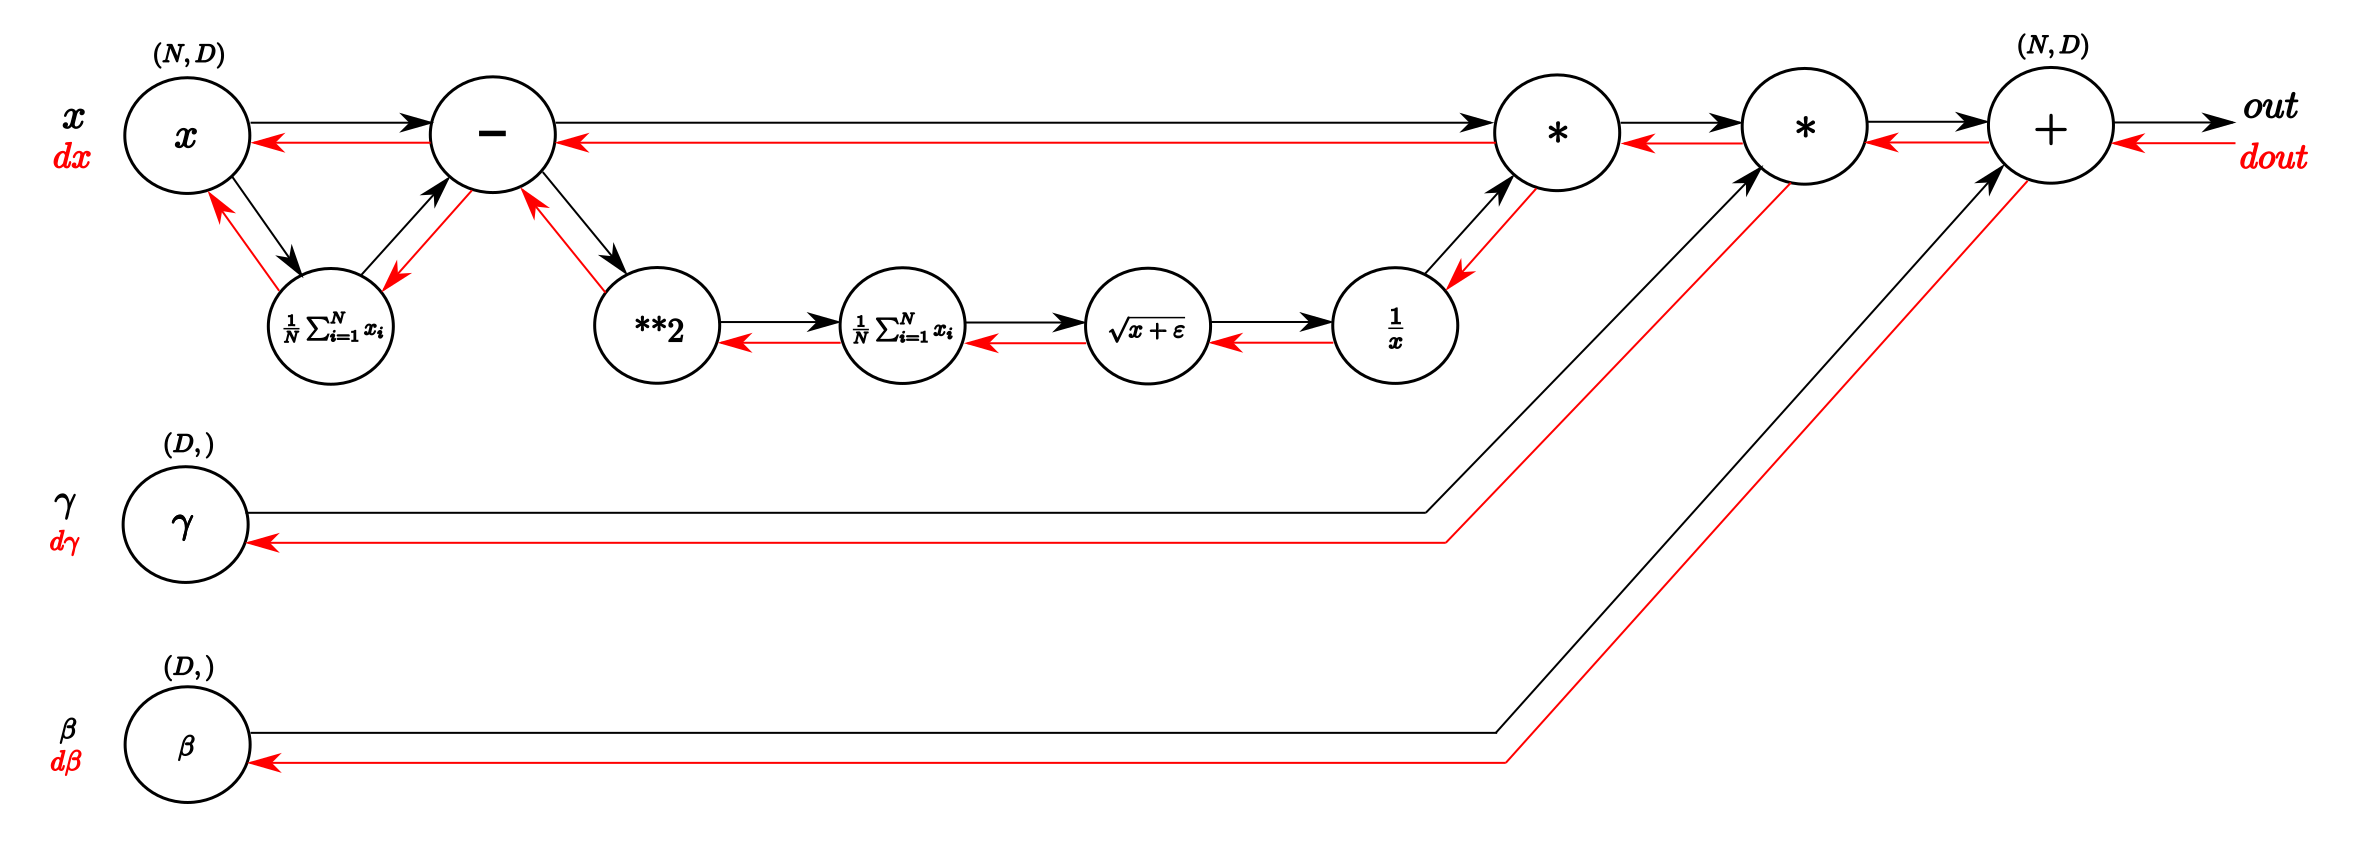

In [12]:
class BatchNormalization:
  """
  http://arxiv.org/abs/1502.03167
  """
  def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
      self.gamma = gamma
      self.beta = beta
      self.momentum = momentum
      self.input_shape = None # Conv 층=4차원, 완전 연결층=2차원

      # 테스트 시 사용하는 평균과 분산(즉, 업데이트 대상)
      self.running_mean = running_mean
      self.running_var = running_var

      # backward 시에 사용하는 중간 데이터
      self.batch_size = None
      self.xc = None
      self.std = None
      self.dgamma = None
      self.dbeta = None

  def forward(self, x, train_flg=True):
      self.input_shape = x.shape
      if x.ndim != 2:
          N, C, H, W = x.shape
          x = x.reshape(N, -1)

      out = self.__forward(x, train_flg)

      return out.reshape(*self.input_shape)


  def __forward(self, x, train_flg):
      if self.running_mean is None:
          N, D = x.shape
          self.running_mean = np.zeros(D)
          self.running_var = np.zeros(D)

      if train_flg:
          mu = x.mean(axis=0)
          xc = x - mu
          var = np.mean(xc**2, axis=0)
          std = np.sqrt(var + 10e-7)
          xn = xc / std

          self.batch_size = x.shape[0]
          self.xc = xc
          self.xn = xn
          self.std = std
          # 평균과 분산의 이동 평균 계산
          self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
          self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
      else:
          # 추론 과정
          xc = x - self.running_mean
          xn = xc / ((np.sqrt(self.running_var + 10e-7)))

      out = self.gamma * xn + self.beta
      return out


  def backward(self, dout):
      if dout.ndim != 2:
          N, C, H, W = dout.shape
          dout = dout.reshape(N, -1)

      dx = self.__backward(dout)

      dx = dx.reshape(*self.input_shape)
      return dx


  def __backward(self, dout):
      dbeta = dout.sum(axis=0)
      dgamma = np.sum(self.xn * dout, axis=0)
      dxn = self.gamma * dout
      dxc = dxn / self.std
      dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)
      dvar = 0.5 * dstd / self.std
      dxc += (2.0 / self.batch_size) * self.xc * dvar
      dmu = np.sum(dxc, axis=0)
      dx = dxc - dmu / self.batch_size

      self.dgamma = dgamma
      self.dbeta = dbeta

      return dx

**Dropout**

In [13]:
class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * ( 1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask

# Training

In [14]:
from torchvision import datasets, transforms

cifar10_train = datasets.MNIST(root='./data', train=True, download=True)
cifar10_test = datasets.MNIST(root='./data', train=False, download=True)

# flatten, normalization
x_train = cifar10_train.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_train = cifar10_train.targets
x_test = cifar10_test.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_test = cifar10_test.targets

# y one-hot encodeing
n = len(np.unique(t_train))
t_train = np.eye(n)[t_train]
t_test = np.eye(n)[t_test]

print(f'x_train.shape: {x_train.shape}')
print(f't_train.shape: {t_train.shape}')

100.0%
100.0%
100.0%
100.0%


x_train.shape: (60000, 784)
t_train.shape: (60000, 10)


정규화 기법을 하나씩 적용해보고, 그렇지 않은 경우의 결과를 비교해보세요!

epoch:0, train acc:0.08666666666666667, test acc:0.1036
epoch:1, train acc:0.07666666666666666, test acc:0.1008
epoch:2, train acc:0.1, test acc:0.1044
epoch:3, train acc:0.12, test acc:0.1116
epoch:4, train acc:0.13666666666666666, test acc:0.1173
epoch:5, train acc:0.16, test acc:0.1295
epoch:6, train acc:0.17666666666666667, test acc:0.1418
epoch:7, train acc:0.19666666666666666, test acc:0.1523
epoch:8, train acc:0.23, test acc:0.1637
epoch:9, train acc:0.24666666666666667, test acc:0.1719
epoch:10, train acc:0.25, test acc:0.1801
epoch:11, train acc:0.2866666666666667, test acc:0.1933
epoch:12, train acc:0.30666666666666664, test acc:0.2071
epoch:13, train acc:0.32666666666666666, test acc:0.2202
epoch:14, train acc:0.36, test acc:0.2405
epoch:15, train acc:0.36666666666666664, test acc:0.2548
epoch:16, train acc:0.39666666666666667, test acc:0.2694
epoch:17, train acc:0.4533333333333333, test acc:0.2862
epoch:18, train acc:0.48, test acc:0.3045
epoch:19, train acc:0.4966666666666

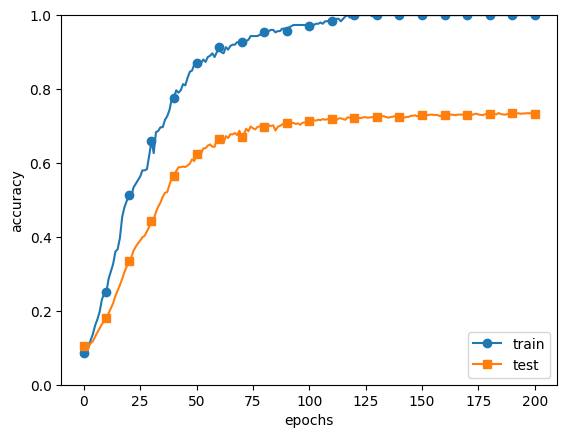

In [15]:
import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [47]:
def experiment(x_train_all, t_train_all, x_test_all, t_test_all, 
               weight_decay_lambda=0, use_dropout=False, dropout_ration=0, 
               use_batchnorm=False, optimizer_ops='SGD', lr = 0.01):

    x_train = x_train_all[:300]
    t_train = t_train_all[:300]
    x_test = x_test_all
    t_test = t_test_all

    network = MultiLayerNet(input_size=784, 
                            hidden_size_list=[100, 100, 100, 100, 100, 100], 
                            output_size=10,
                            weight_decay_lambda=weight_decay_lambda, 
                            use_dropout=use_dropout, 
                            dropout_ration=dropout_ration, 
                            use_batchnorm=use_batchnorm)

    if optimizer_ops.lower() == 'sgd':
        optimizer = SGD(lr=lr)
    elif optimizer_ops.lower() == 'adam':
        optimizer = Adam(lr=lr)
    else:
        optimizer = SGD(lr=lr)

    max_epochs = 201
    train_size = x_train.shape[0]
    batch_size = 100
    
    train_acc_list = []
    test_acc_list = []

    iter_per_epoch = int(max(train_size / batch_size, 1))
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)

            if epoch_cnt % 20 == 0:
                print(f"epoch: {epoch_cnt} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    # 4. 결과 시각화
    plt.plot(np.arange(max_epochs), train_acc_list, marker='o', label='train', markevery=10)
    plt.plot(np.arange(max_epochs), test_acc_list, marker='s', label='test', markevery=10)
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.ylim(0, 1.0)
    plt.legend(loc='lower right')
    plt.show()

#### 1. 하나씩 실험

##### (0) 기본 모델 다시

epoch: 0 | train acc: 0.1200 | test acc: 0.1159
epoch: 20 | train acc: 0.5800 | test acc: 0.3919
epoch: 40 | train acc: 0.8700 | test acc: 0.6480
epoch: 60 | train acc: 0.9467 | test acc: 0.7057
epoch: 80 | train acc: 0.9867 | test acc: 0.7293
epoch: 100 | train acc: 1.0000 | test acc: 0.7358
epoch: 120 | train acc: 1.0000 | test acc: 0.7382
epoch: 140 | train acc: 1.0000 | test acc: 0.7426
epoch: 160 | train acc: 1.0000 | test acc: 0.7426
epoch: 180 | train acc: 1.0000 | test acc: 0.7451
epoch: 200 | train acc: 1.0000 | test acc: 0.7469


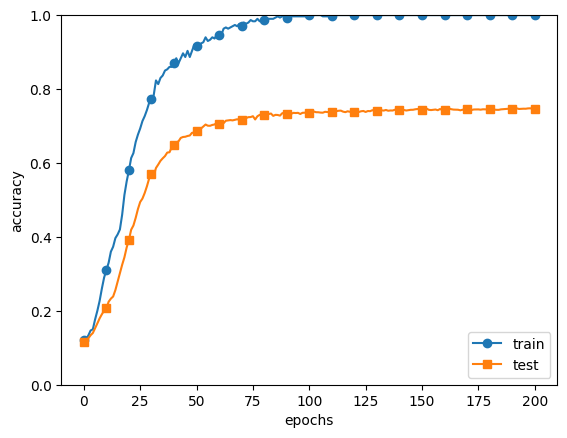

In [44]:
experiment(x_train, t_train, x_test, t_test)

##### (1) weight decay

epoch: 0 | train acc: 0.1533 | test acc: 0.1213
epoch: 20 | train acc: 0.4967 | test acc: 0.3745
epoch: 40 | train acc: 0.6633 | test acc: 0.4958
epoch: 60 | train acc: 0.7933 | test acc: 0.6229
epoch: 80 | train acc: 0.8300 | test acc: 0.6753
epoch: 100 | train acc: 0.8700 | test acc: 0.7051
epoch: 120 | train acc: 0.8800 | test acc: 0.7250
epoch: 140 | train acc: 0.8967 | test acc: 0.7427
epoch: 160 | train acc: 0.9067 | test acc: 0.7483
epoch: 180 | train acc: 0.8967 | test acc: 0.7382
epoch: 200 | train acc: 0.9133 | test acc: 0.7474


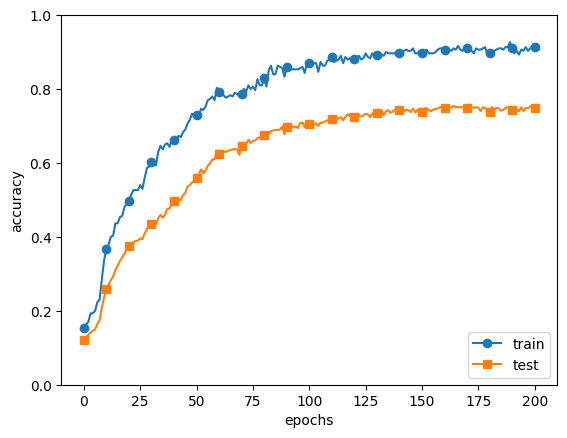

In [33]:
experiment(x_train, t_train, x_test, t_test, weight_decay_lambda=0.1)

epoch: 0 | train acc: 0.1133 | test acc: 0.1156
epoch: 20 | train acc: 0.4033 | test acc: 0.2911
epoch: 40 | train acc: 0.5700 | test acc: 0.4121
epoch: 60 | train acc: 0.7600 | test acc: 0.5479
epoch: 80 | train acc: 0.8633 | test acc: 0.6386
epoch: 100 | train acc: 0.9067 | test acc: 0.6916
epoch: 120 | train acc: 0.9333 | test acc: 0.7137
epoch: 140 | train acc: 0.9533 | test acc: 0.7378
epoch: 160 | train acc: 0.9667 | test acc: 0.7469
epoch: 180 | train acc: 0.9667 | test acc: 0.7533
epoch: 200 | train acc: 0.9733 | test acc: 0.7578


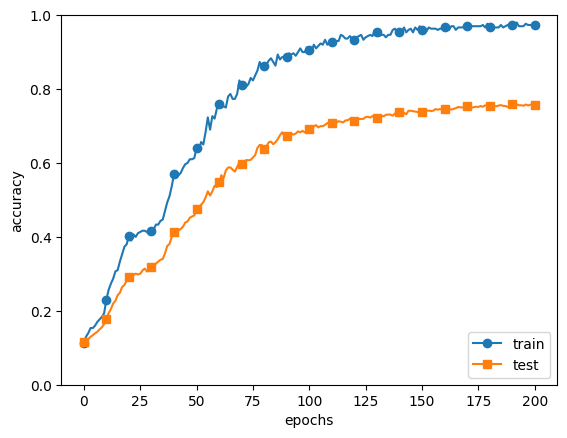

In [34]:
experiment(x_train, t_train, x_test, t_test, weight_decay_lambda=0.05)

##### (2) Dropout

epoch: 0 | train acc: 0.0667 | test acc: 0.0920
epoch: 20 | train acc: 0.2467 | test acc: 0.1729
epoch: 40 | train acc: 0.3200 | test acc: 0.2300
epoch: 60 | train acc: 0.4467 | test acc: 0.3321
epoch: 80 | train acc: 0.6233 | test acc: 0.4486
epoch: 100 | train acc: 0.6867 | test acc: 0.5078
epoch: 120 | train acc: 0.7767 | test acc: 0.5783
epoch: 140 | train acc: 0.8100 | test acc: 0.5991
epoch: 160 | train acc: 0.8633 | test acc: 0.6445
epoch: 180 | train acc: 0.9100 | test acc: 0.6801
epoch: 200 | train acc: 0.9300 | test acc: 0.6969


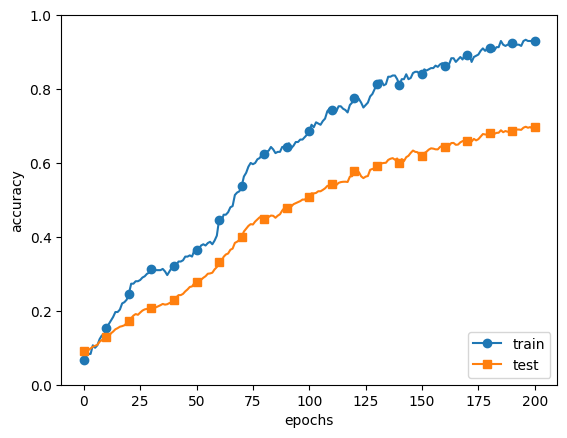

In [41]:
experiment(x_train, t_train, x_test, t_test,  use_dropout = True, dropout_ration = 0.1)

epoch: 0 | train acc: 0.0900 | test acc: 0.1153
epoch: 20 | train acc: 0.3600 | test acc: 0.3126
epoch: 40 | train acc: 0.6233 | test acc: 0.4636
epoch: 60 | train acc: 0.7900 | test acc: 0.6121
epoch: 80 | train acc: 0.8767 | test acc: 0.6922
epoch: 100 | train acc: 0.9133 | test acc: 0.7364
epoch: 120 | train acc: 0.9367 | test acc: 0.7538
epoch: 140 | train acc: 0.9700 | test acc: 0.7701
epoch: 160 | train acc: 0.9800 | test acc: 0.7732
epoch: 180 | train acc: 0.9867 | test acc: 0.7783
epoch: 200 | train acc: 0.9967 | test acc: 0.7829


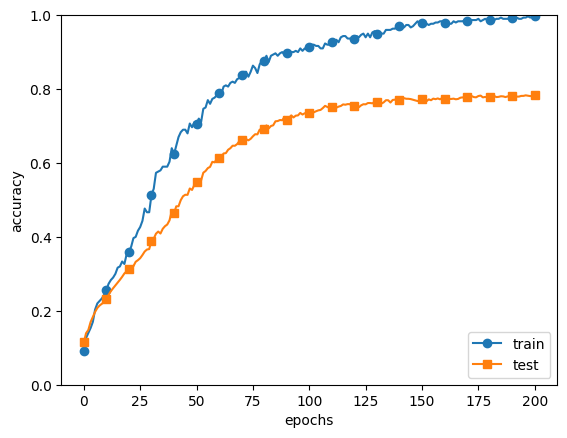

In [42]:
experiment(x_train, t_train, x_test, t_test,  use_dropout = True, dropout_ration = 0.05)

##### (3) BN

epoch: 0 | train acc: 0.1233 | test acc: 0.1117
epoch: 20 | train acc: 0.9500 | test acc: 0.3853
epoch: 40 | train acc: 0.9967 | test acc: 0.4730
epoch: 60 | train acc: 1.0000 | test acc: 0.5124
epoch: 80 | train acc: 1.0000 | test acc: 0.5380
epoch: 100 | train acc: 1.0000 | test acc: 0.5478
epoch: 120 | train acc: 1.0000 | test acc: 0.5553
epoch: 140 | train acc: 1.0000 | test acc: 0.5622
epoch: 160 | train acc: 1.0000 | test acc: 0.5687
epoch: 180 | train acc: 1.0000 | test acc: 0.5696
epoch: 200 | train acc: 1.0000 | test acc: 0.5752


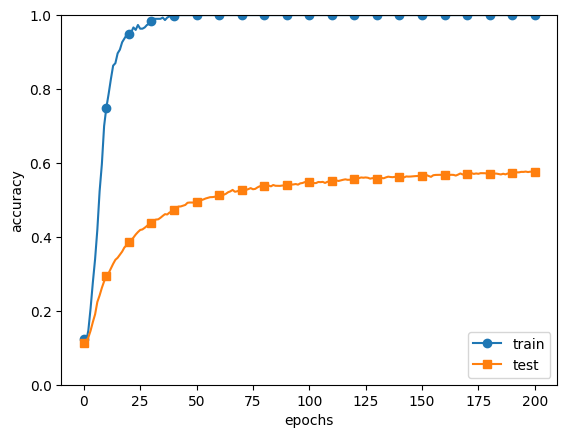

In [ ]:
experiment(x_train, t_train, x_test, t_test, use_batchnorm=True)

##### (4) Adam

epoch: 0 | train acc: 0.1033 | test acc: 0.1037
epoch: 20 | train acc: 0.9867 | test acc: 0.7581
epoch: 40 | train acc: 0.9233 | test acc: 0.6911
epoch: 60 | train acc: 1.0000 | test acc: 0.7659
epoch: 80 | train acc: 1.0000 | test acc: 0.7672
epoch: 100 | train acc: 1.0000 | test acc: 0.7685
epoch: 120 | train acc: 1.0000 | test acc: 0.7679
epoch: 140 | train acc: 1.0000 | test acc: 0.7680
epoch: 160 | train acc: 1.0000 | test acc: 0.7679
epoch: 180 | train acc: 1.0000 | test acc: 0.7683
epoch: 200 | train acc: 1.0000 | test acc: 0.7683


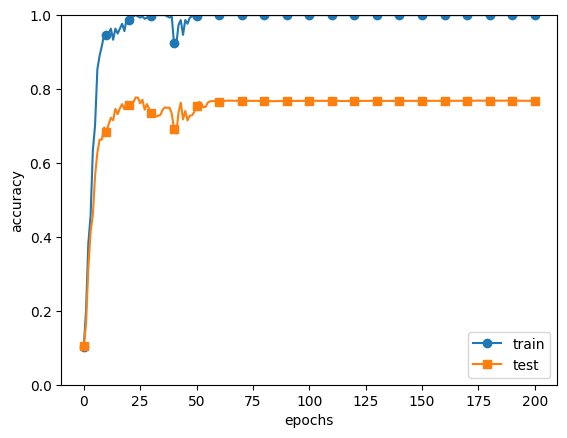

In [45]:
experiment(x_train, t_train, x_test, t_test, optimizer_ops = 'Adam')

#### 2. 혼합

epoch: 0 | train acc: 0.0800 | test acc: 0.0873
epoch: 20 | train acc: 0.4333 | test acc: 0.3236
epoch: 40 | train acc: 0.5733 | test acc: 0.4292
epoch: 60 | train acc: 0.7267 | test acc: 0.5340
epoch: 80 | train acc: 0.8267 | test acc: 0.6362
epoch: 100 | train acc: 0.9433 | test acc: 0.7278
epoch: 120 | train acc: 0.9767 | test acc: 0.7691
epoch: 140 | train acc: 0.9933 | test acc: 0.7885
epoch: 160 | train acc: 0.9933 | test acc: 0.7941
epoch: 180 | train acc: 1.0000 | test acc: 0.8004
epoch: 200 | train acc: 1.0000 | test acc: 0.8029


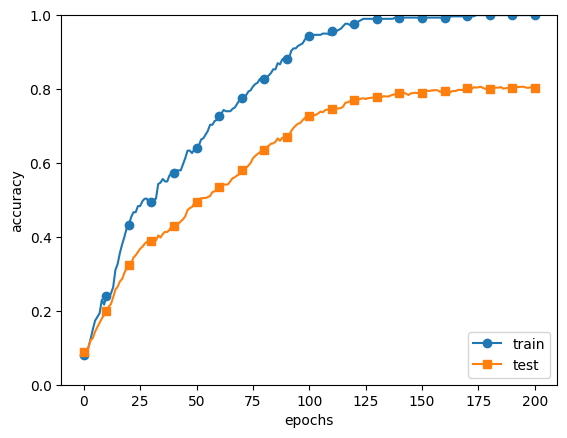

In [70]:
experiment(x_train, t_train, x_test, t_test, 
           weight_decay_lambda = 0.01,
           use_dropout = True,
           dropout_ration = 0.3,
           optimizer_ops = 'Adam',
           use_batchnorm = True,
           lr = 0.0005)

epoch: 0 | train acc: 0.0733 | test acc: 0.0839
epoch: 20 | train acc: 0.8433 | test acc: 0.6408
epoch: 40 | train acc: 0.9833 | test acc: 0.7499
epoch: 60 | train acc: 1.0000 | test acc: 0.7669
epoch: 80 | train acc: 1.0000 | test acc: 0.7757
epoch: 100 | train acc: 1.0000 | test acc: 0.7833
epoch: 120 | train acc: 1.0000 | test acc: 0.7905
epoch: 140 | train acc: 1.0000 | test acc: 0.7837
epoch: 160 | train acc: 1.0000 | test acc: 0.7846
epoch: 180 | train acc: 1.0000 | test acc: 0.7879
epoch: 200 | train acc: 1.0000 | test acc: 0.7846


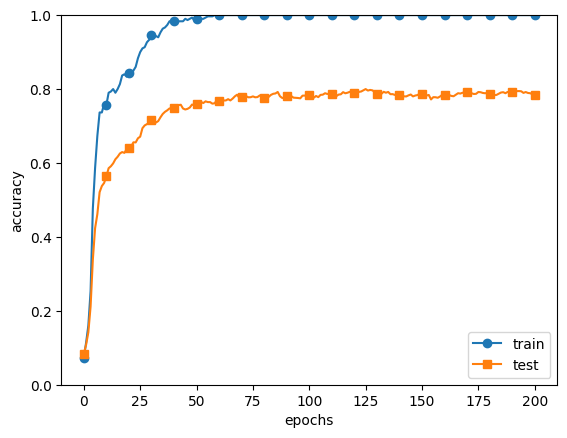

In [72]:
experiment(x_train, t_train, x_test, t_test,
           weight_decay_lambda = 0.01,
           use_dropout = True,
           dropout_ration = 0.2,
           use_batchnorm = True,
           optimizer_ops = 'SDG',
           lr = 0.1)